# Azure LLM Inference Trace Analysis for P1 Bounded Derivation

**Source:** AzureLLMInferenceDataset2024 (DynamoLLM, Stojkovic et al. HPCA 2025)  
**Purpose:** Extract empirical parameters for Pillar 1 workload flexibility estimates  
**Traces:** ~44M production Azure LLM inference requests over one week (May 2024)  

---

### Parameters we need to compute:

| Parameter | What it tells us | P1 Factor |
|-----------|------------------|-----------|
| Hourly load CoV (request + token-weighted) | Natural temporal slack | C (latency tolerance via destination headroom) |
| 24h autocorrelation | Predictability of diurnal cycle | Scheduling feasibility |
| Peak-to-trough ratio (daily) | Max headroom at destination facilities | C |
| Weekend vs weekday load | Additional temporal slack | C |
| Request duration distribution | Facility drain time after stop-routing | DR response time |
| Request independence metrics | Statelessness confirmation | A |
| Token distributions | Compute intensity profile | General characterization |

## 0. Setup and Data Loading

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Publication-quality plot settings
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Where to save publication figures
import os
FIG_DIR = 'figures_azure_trace'
os.makedirs(FIG_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# Update these paths to wherever you saved the files:
CODE_PATH = r'C:\Users\dunla\OneDrive\Documents\Bartlett Fellowship\Thesis\Data\Azure_Traces\AzureLLMInferenceTrace_code_1week.csv'
CONV_PATH = r'C:\Users\dunla\OneDrive\Documents\Bartlett Fellowship\Thesis\Data\Azure_Traces\AzureLLMInferenceTrace_conv_1week.csv'

print(f'Loading coding trace from: {CODE_PATH}')
print('This may take 2-5 minutes per file due to mixed timestamp parsing...')

Loading coding trace from: C:\Users\dunla\OneDrive\Documents\Bartlett Fellowship\Thesis\Data\Azure_Traces\AzureLLMInferenceTrace_code_1week.csv
This may take 2-5 minutes per file due to mixed timestamp parsing...


In [3]:
%%time
df_code = pd.read_csv(
    CODE_PATH, 
    parse_dates=['TIMESTAMP'], 
    date_format='mixed', 
    dayfirst=False
)
print(f'Coding trace: {len(df_code):,} requests')
print(f'Period: {df_code["TIMESTAMP"].min()} to {df_code["TIMESTAMP"].max()}')
df_code.head()

Coding trace: 16,803,695 requests


Period: 2024-05-10 00:00:00.009930+00:00 to 2024-05-16 23:59:59.929501+00:00
CPU times: total: 3min 20s
Wall time: 4min 21s


,TIMESTAMP,ContextTokens,GeneratedTokens
0,2024-05-10 00:00:00.009930+00:00,2162,5
1,2024-05-10 00:00:00.017335+00:00,2399,6
2,2024-05-10 00:00:00.022314+00:00,76,15
3,2024-05-10 00:00:00.037845+00:00,2376,1
4,2024-05-10 00:00:00.083890+00:00,7670,8


In [4]:
%%time
df_conv = pd.read_csv(
    CONV_PATH, 
    parse_dates=['TIMESTAMP'], 
    date_format='mixed', 
    dayfirst=False
)
print(f'Conversation trace: {len(df_conv):,} requests')
print(f'Period: {df_conv["TIMESTAMP"].min()} to {df_conv["TIMESTAMP"].max()}')
df_conv.head()

Conversation trace: 27,303,999 requests


Period: 2024-05-12 00:00:00.001163+00:00 to 2024-05-18 23:59:59.995460+00:00
CPU times: total: 7min 34s
Wall time: 12min 8s


,TIMESTAMP,ContextTokens,GeneratedTokens
0,2024-05-12 00:00:00.001163+00:00,1452,3
1,2024-05-12 00:00:00.041683+00:00,584,3
2,2024-05-12 00:00:00.157988+00:00,862,38
3,2024-05-12 00:00:00.158932+00:00,1569,3
4,2024-05-12 00:00:00.248279+00:00,617,104


In [5]:
traces = {'Coding': df_code, 'Conversation': df_conv}

for name, df in traces.items():
    total_tokens = df['ContextTokens'].sum() + df['GeneratedTokens'].sum()
    print(f'\n{name}:')
    print(f'  Requests: {len(df):,}')
    print(f'  Total tokens processed: {total_tokens:,.0f}')
    print(f'  Days covered: {(df["TIMESTAMP"].max() - df["TIMESTAMP"].min()).days}')
    print(f'  Avg requests/sec: {len(df) / (df["TIMESTAMP"].max() - df["TIMESTAMP"].min()).total_seconds():.1f}')


Coding:
  Requests: 16,803,695
  Total tokens processed: 42,579,982,075


  Days covered: 6
  Avg requests/sec: 27.8



Conversation:
  Requests: 27,303,999
  Total tokens processed: 47,429,468,868


  Days covered: 6


  Avg requests/sec: 45.1


---
## 1. Hourly Aggregation

Build hourly time series for both request counts and token throughput.  
These are the base series for all temporal analyses.

In [6]:
def build_hourly(df, name):
    """Aggregate to hourly bins: request count, total tokens, compute-weighted tokens."""
    df = df.copy()
    df['hour'] = df['TIMESTAMP'].dt.floor('h')
    df['TotalTokens'] = df['ContextTokens'] + df['GeneratedTokens']
    
    hourly = df.groupby('hour').agg(
        request_count=('TIMESTAMP', 'count'),
        context_tokens=('ContextTokens', 'sum'),
        generated_tokens=('GeneratedTokens', 'sum'),
        total_tokens=('TotalTokens', 'sum'),
        median_context=('ContextTokens', 'median'),
        p90_context=('ContextTokens', lambda x: x.quantile(0.9)),
        median_generated=('GeneratedTokens', 'median'),
        p90_generated=('GeneratedTokens', lambda x: x.quantile(0.9)),
    ).sort_index()
    
    hourly['day_of_week'] = hourly.index.dayofweek  # 0=Monday, 6=Sunday
    hourly['hour_of_day'] = hourly.index.hour
    hourly['is_weekend'] = hourly['day_of_week'].isin([5, 6])
    hourly['day_name'] = hourly.index.strftime('%A')
    
    return hourly

hourly = {}
for name, df in traces.items():
    hourly[name] = build_hourly(df, name)
    print(f'{name}: {len(hourly[name])} hourly bins')

hourly['Coding'].head(10)

Coding: 168 hourly bins


Conversation: 168 hourly bins


,request_count,context_tokens,generated_tokens,total_tokens,median_context,p90_context,median_generated,p90_generated,day_of_week,hour_of_day,is_weekend,day_name
hour,,,,,,,,,,,,
2024-05-10 00:00:00+00:00,77540,191030427,1950802,192981229,1955.0,5884.0,9.0,49.0,4,0,False,Friday
2024-05-10 01:00:00+00:00,76895,172724830,1898068,174622898,1652.0,5543.6,9.0,49.0,4,1,False,Friday
2024-05-10 02:00:00+00:00,66953,162954792,1721114,164675906,1825.0,6225.0,9.0,49.0,4,2,False,Friday
2024-05-10 03:00:00+00:00,57781,142495634,1451475,143947109,1865.0,6313.0,9.0,48.0,4,3,False,Friday
2024-05-10 04:00:00+00:00,46575,123213394,1157315,124370709,2095.0,7125.0,9.0,47.0,4,4,False,Friday
2024-05-10 05:00:00+00:00,38670,94751957,984351,95736308,1933.0,5869.0,9.0,48.0,4,5,False,Friday
2024-05-10 06:00:00+00:00,32595,83413090,850672,84263762,1817.0,6785.8,9.0,49.0,4,6,False,Friday
2024-05-10 07:00:00+00:00,29267,76844759,734632,77579391,1903.0,6774.6,10.0,45.0,4,7,False,Friday
2024-05-10 08:00:00+00:00,25758,68051750,623697,68675447,1888.5,7222.8,10.0,43.0,4,8,False,Friday


---
## 2. Diurnal Load Profile & Peak-to-Trough Ratio

**Target parameter:** Peak-to-trough ratio (request-weighted and token-weighted)  
**P1 relevance:** Quantifies natural headroom at destination facilities during off-peak hours

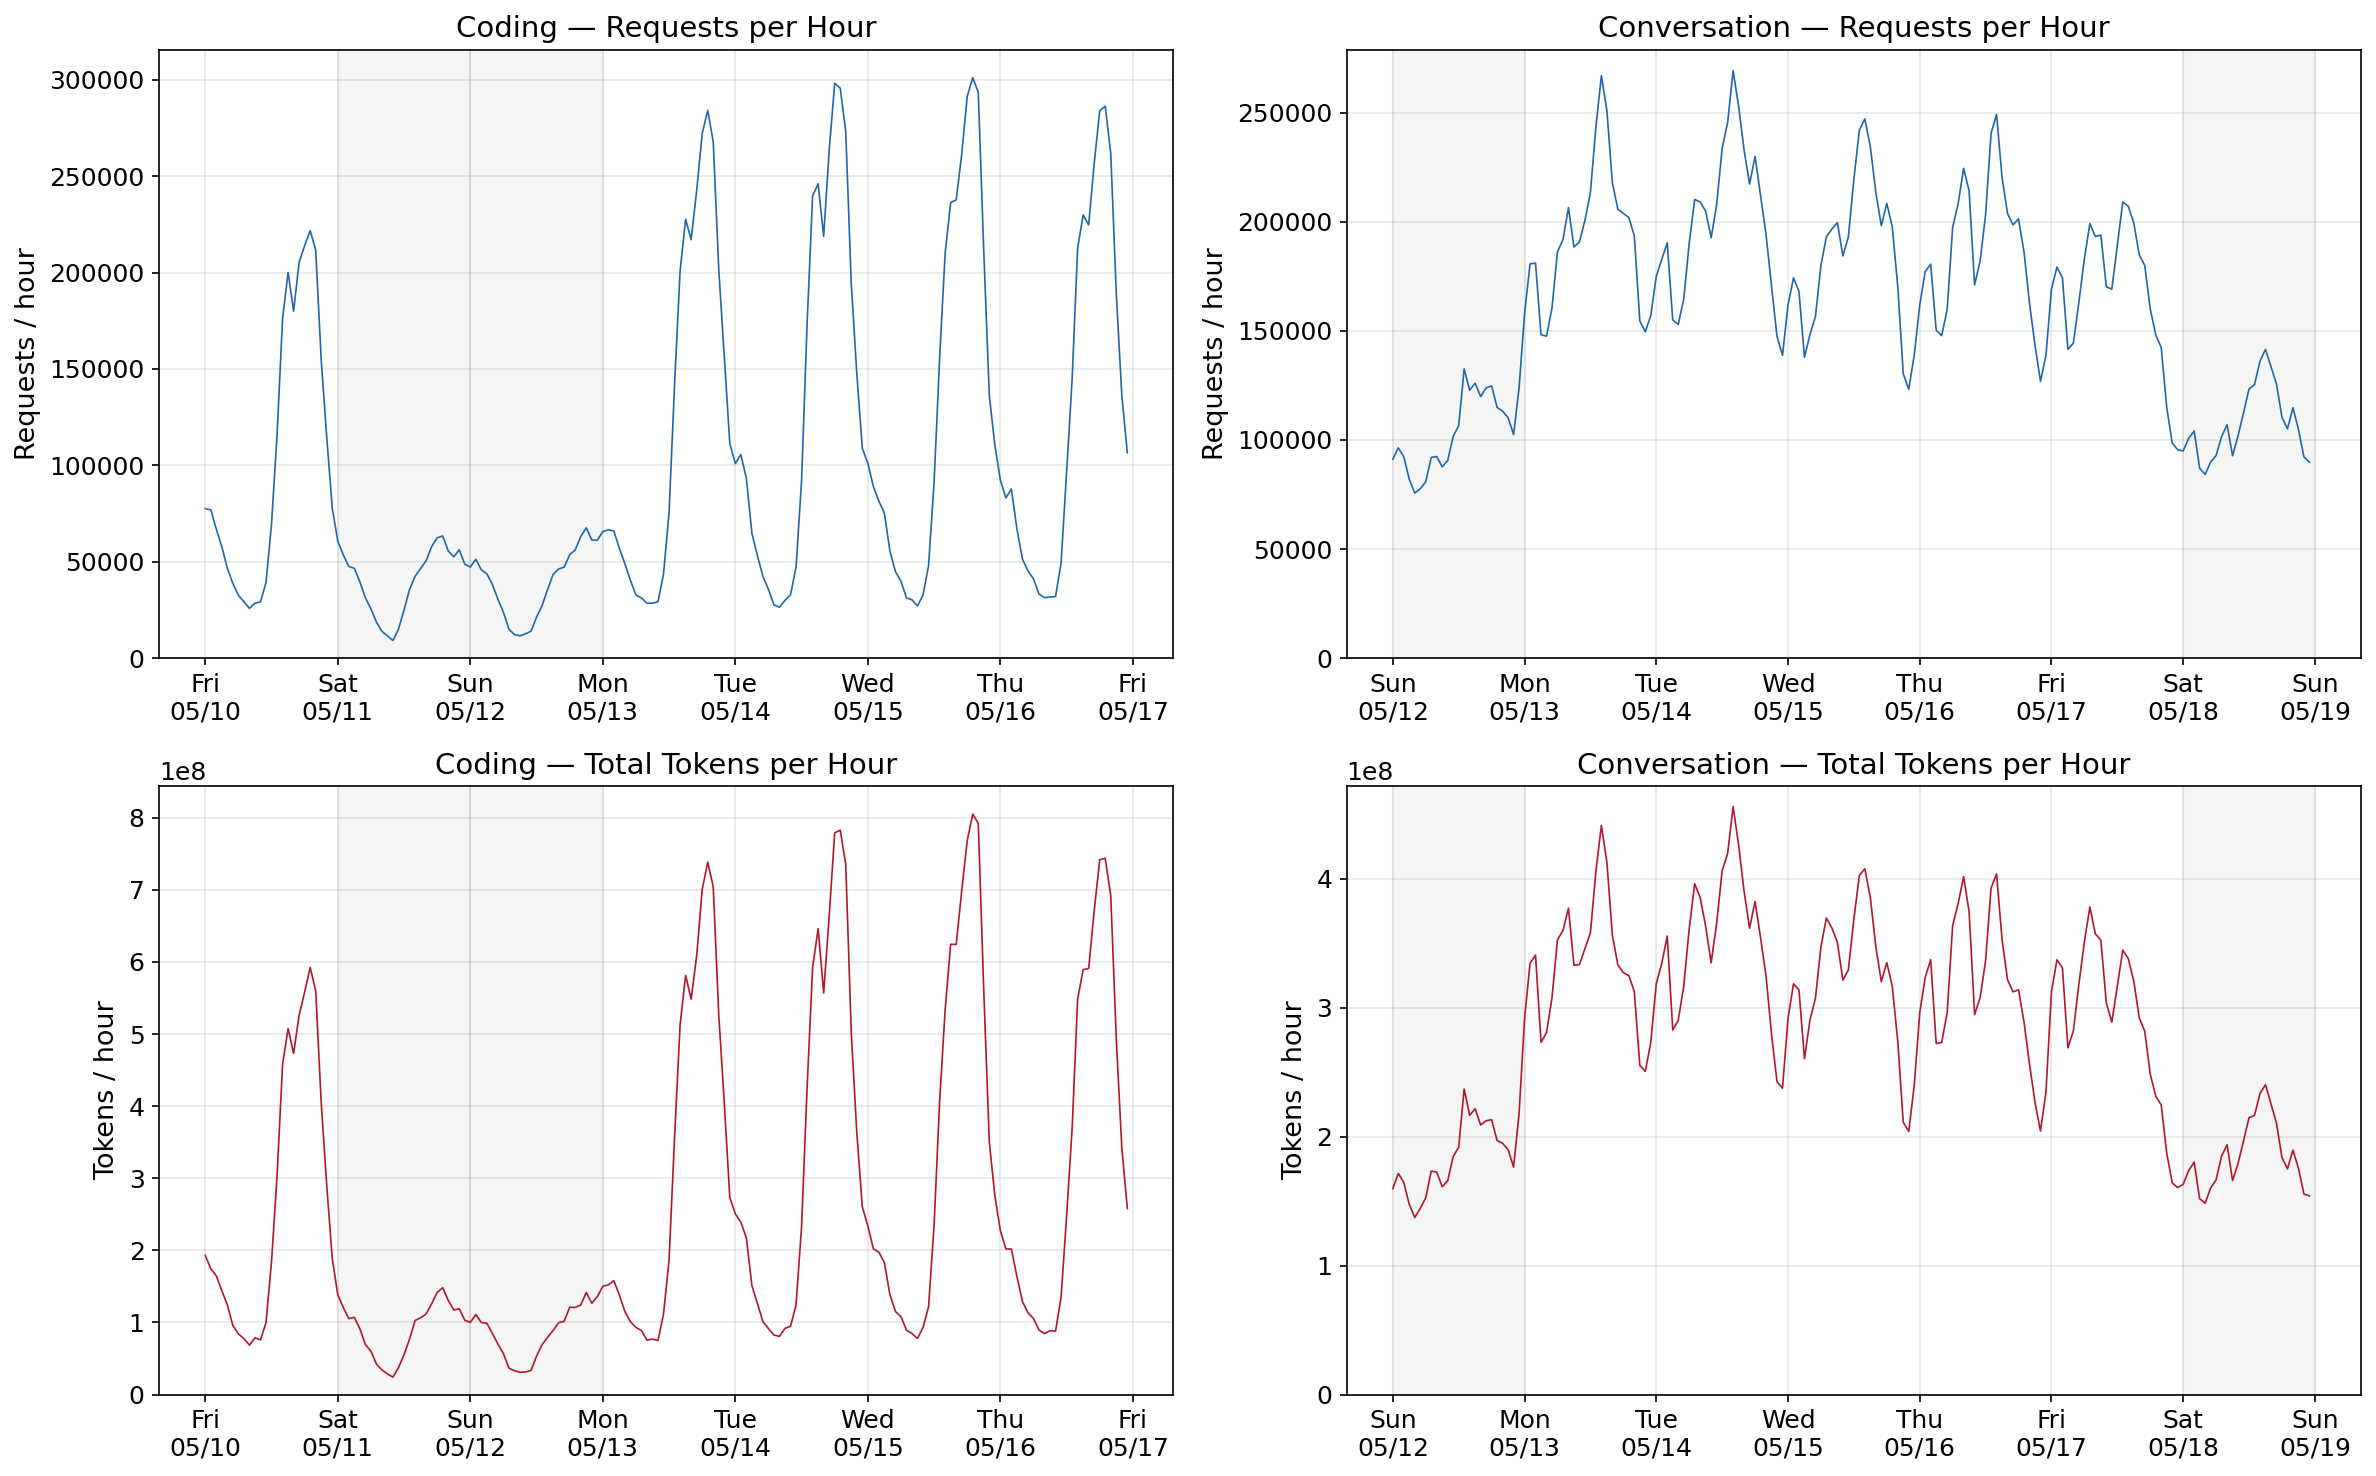

Gray shading = weekend days


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, (name, h) in enumerate(hourly.items()):
    # Request count time series
    ax = axes[0, i]
    ax.plot(h.index, h['request_count'], linewidth=0.8, color='#2166ac')
    ax.set_title(f'{name} — Requests per Hour')
    ax.set_ylabel('Requests / hour')
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%m/%d'))
    
    # Shade weekends
    for idx, row in h.iterrows():
        if row['is_weekend'] and row['hour_of_day'] == 0:
            ax.axvspan(idx, idx + pd.Timedelta(hours=24), alpha=0.08, color='gray')
    
    # Token throughput time series
    ax = axes[1, i]
    ax.plot(h.index, h['total_tokens'], linewidth=0.8, color='#b2182b')
    ax.set_title(f'{name} — Total Tokens per Hour')
    ax.set_ylabel('Tokens / hour')
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%m/%d'))
    
    for idx, row in h.iterrows():
        if row['is_weekend'] and row['hour_of_day'] == 0:
            ax.axvspan(idx, idx + pd.Timedelta(hours=24), alpha=0.08, color='gray')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/diurnal_timeseries.png')
plt.show()
print('Gray shading = weekend days')

In [8]:
# === PEAK-TO-TROUGH RATIOS ===

print('=' * 70)
print('PEAK-TO-TROUGH RATIOS (by day)')
print('=' * 70)

pttr_summary = []

for name, h in hourly.items():
    print(f'\n--- {name} ---')
    
    # Group by date
    for date, day_data in h.groupby(h.index.date):
        if len(day_data) < 20:  # skip partial days
            continue
        
        peak_req = day_data['request_count'].max()
        trough_req = day_data['request_count'].min()
        ratio_req = peak_req / trough_req if trough_req > 0 else np.inf
        
        peak_tok = day_data['total_tokens'].max()
        trough_tok = day_data['total_tokens'].min()
        ratio_tok = peak_tok / trough_tok if trough_tok > 0 else np.inf
        
        dow = day_data['day_name'].iloc[0]
        is_wknd = day_data['is_weekend'].iloc[0]
        
        print(f'  {date} ({dow:>9s}): '
              f'Requests {ratio_req:5.1f}:1  '
              f'Tokens {ratio_tok:5.1f}:1  '
              f'{"  [WEEKEND]" if is_wknd else ""}')
        
        pttr_summary.append({
            'trace': name, 'date': date, 'day': dow,
            'is_weekend': is_wknd,
            'pttr_requests': ratio_req, 'pttr_tokens': ratio_tok,
            'peak_requests': peak_req, 'trough_requests': trough_req,
        })

pttr_df = pd.DataFrame(pttr_summary)

print('\n' + '=' * 70)
print('SUMMARY')
print('=' * 70)
for name in ['Coding', 'Conversation']:
    subset = pttr_df[pttr_df['trace'] == name]
    weekday = subset[~subset['is_weekend']]
    weekend = subset[subset['is_weekend']]
    print(f'\n{name}:')
    print(f'  Weekday request PTTR: {weekday["pttr_requests"].mean():.1f}:1 '
          f'(range {weekday["pttr_requests"].min():.1f}–{weekday["pttr_requests"].max():.1f})')
    print(f'  Weekday token PTTR:   {weekday["pttr_tokens"].mean():.1f}:1 '
          f'(range {weekday["pttr_tokens"].min():.1f}–{weekday["pttr_tokens"].max():.1f})')
    if len(weekend) > 0:
        print(f'  Weekend request PTTR: {weekend["pttr_requests"].mean():.1f}:1')
        print(f'  Weekend token PTTR:   {weekend["pttr_tokens"].mean():.1f}:1')

PEAK-TO-TROUGH RATIOS (by day)

--- Coding ---
  2024-05-10 (   Friday): Requests   8.6:1  Tokens   8.6:1  
  2024-05-11 ( Saturday): Requests   7.0:1  Tokens   6.1:1    [WEEKEND]
  2024-05-12 (   Sunday): Requests   5.9:1  Tokens   4.6:1    [WEEKEND]
  2024-05-13 (   Monday): Requests  10.0:1  Tokens   9.8:1  
  2024-05-14 (  Tuesday): Requests  11.3:1  Tokens   9.7:1  
  2024-05-15 (Wednesday): Requests  11.1:1  Tokens  10.3:1  
  2024-05-16 ( Thursday): Requests   9.1:1  Tokens   8.8:1  

--- Conversation ---
  2024-05-12 (   Sunday): Requests   1.8:1  Tokens   1.7:1    [WEEKEND]
  2024-05-13 (   Monday): Requests   1.8:1  Tokens   1.8:1  
  2024-05-14 (  Tuesday): Requests   1.9:1  Tokens   1.9:1  
  2024-05-15 (Wednesday): Requests   2.0:1  Tokens   2.0:1  
  2024-05-16 ( Thursday): Requests   2.0:1  Tokens   2.0:1  
  2024-05-17 (   Friday): Requests   2.2:1  Tokens   2.4:1  
  2024-05-18 ( Saturday): Requests   1.7:1  Tokens   1.6:1    [WEEKEND]

SUMMARY

Coding:
  Weekday reque

---
## 3. Coefficient of Variation

**Target parameter:** Hourly load CoV (σ/μ)  
**P1 relevance:** Higher CoV = more temporal variability = more exploitable slack for DR

In [9]:
print('=' * 70)
print('COEFFICIENT OF VARIATION (hourly bins)')
print('=' * 70)

for name, h in hourly.items():
    print(f'\n--- {name} ---')
    
    # Overall
    cov_req = h['request_count'].std() / h['request_count'].mean()
    cov_tok = h['total_tokens'].std() / h['total_tokens'].mean()
    print(f'  Overall (all hours):')
    print(f'    Request count CoV: {cov_req:.3f}')
    print(f'    Token throughput CoV: {cov_tok:.3f}')
    
    # Weekday only
    wd = h[~h['is_weekend']]
    cov_req_wd = wd['request_count'].std() / wd['request_count'].mean()
    cov_tok_wd = wd['total_tokens'].std() / wd['total_tokens'].mean()
    print(f'  Weekdays only:')
    print(f'    Request count CoV: {cov_req_wd:.3f}')
    print(f'    Token throughput CoV: {cov_tok_wd:.3f}')
    
    # Weekend only
    we = h[h['is_weekend']]
    if len(we) > 0:
        cov_req_we = we['request_count'].std() / we['request_count'].mean()
        cov_tok_we = we['total_tokens'].std() / we['total_tokens'].mean()
        print(f'  Weekends only:')
        print(f'    Request count CoV: {cov_req_we:.3f}')
        print(f'    Token throughput CoV: {cov_tok_we:.3f}')

COEFFICIENT OF VARIATION (hourly bins)

--- Coding ---
  Overall (all hours):
    Request count CoV: 0.848
    Token throughput CoV: 0.883
  Weekdays only:
    Request count CoV: 0.716
    Token throughput CoV: 0.730
  Weekends only:
    Request count CoV: 0.444
    Token throughput CoV: 0.417

--- Conversation ---
  Overall (all hours):
    Request count CoV: 0.291
    Token throughput CoV: 0.284
  Weekdays only:
    Request count CoV: 0.185
    Token throughput CoV: 0.179
  Weekends only:
    Request count CoV: 0.160
    Token throughput CoV: 0.145


---
## 4. Autocorrelation at 24h Lag

**Target parameter:** ρ(24h) — autocorrelation of hourly load at 24-hour lag  
**P1 relevance:** High autocorrelation = predictable diurnal cycle = schedulable DR commitment  
**Benchmark:** SageServe (Microsoft 2025) reported ~0.95 for O365 Copilot workloads

AUTOCORRELATION ANALYSIS


  Coding — Request count: ρ(24h) = 0.7545


  Coding — Token throughput: ρ(24h) = 0.7415


  Conversation — Request count: ρ(24h) = 0.3995


  Conversation — Token throughput: ρ(24h) = 0.3607


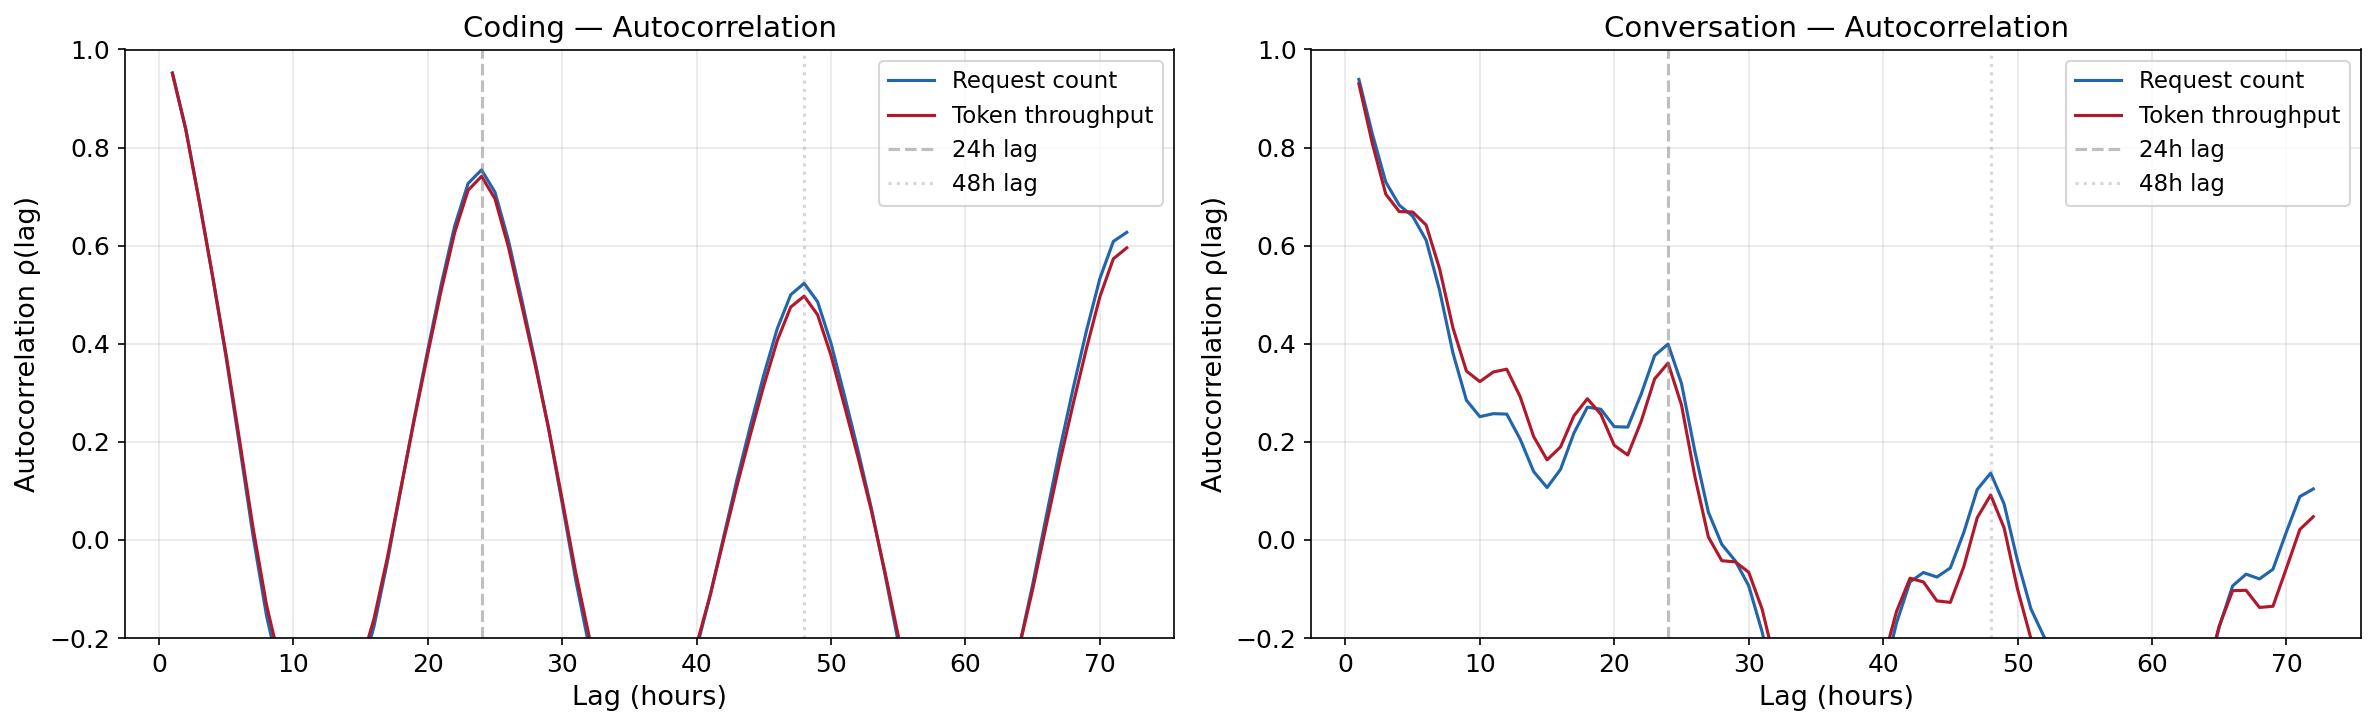

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

print('=' * 70)
print('AUTOCORRELATION ANALYSIS')
print('=' * 70)

max_lag = 72  # 3 days of hourly lags

for i, (name, h) in enumerate(hourly.items()):
    ax = axes[i]
    
    # Compute autocorrelation for request count and token throughput
    for series_name, col, color in [
        ('Request count', 'request_count', '#2166ac'),
        ('Token throughput', 'total_tokens', '#b2182b'),
    ]:
        acf_vals = [h[col].autocorr(lag=lag) for lag in range(1, max_lag + 1)]
        ax.plot(range(1, max_lag + 1), acf_vals, label=series_name, 
                color=color, linewidth=1.5)
        
        # Report 24h lag specifically
        rho_24 = h[col].autocorr(lag=24)
        print(f'  {name} — {series_name}: ρ(24h) = {rho_24:.4f}')
    
    ax.axvline(x=24, color='gray', linestyle='--', alpha=0.5, label='24h lag')
    ax.axvline(x=48, color='gray', linestyle=':', alpha=0.3, label='48h lag')
    ax.set_title(f'{name} — Autocorrelation')
    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('Autocorrelation ρ(lag)')
    ax.set_ylim(-0.2, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/autocorrelation.png')
plt.show()

---
## 5. Average Diurnal Profile (Hour-of-Day)

Collapse across days to get the mean hourly profile with confidence bands.  
This is the canonical "what does a typical day look like" figure.

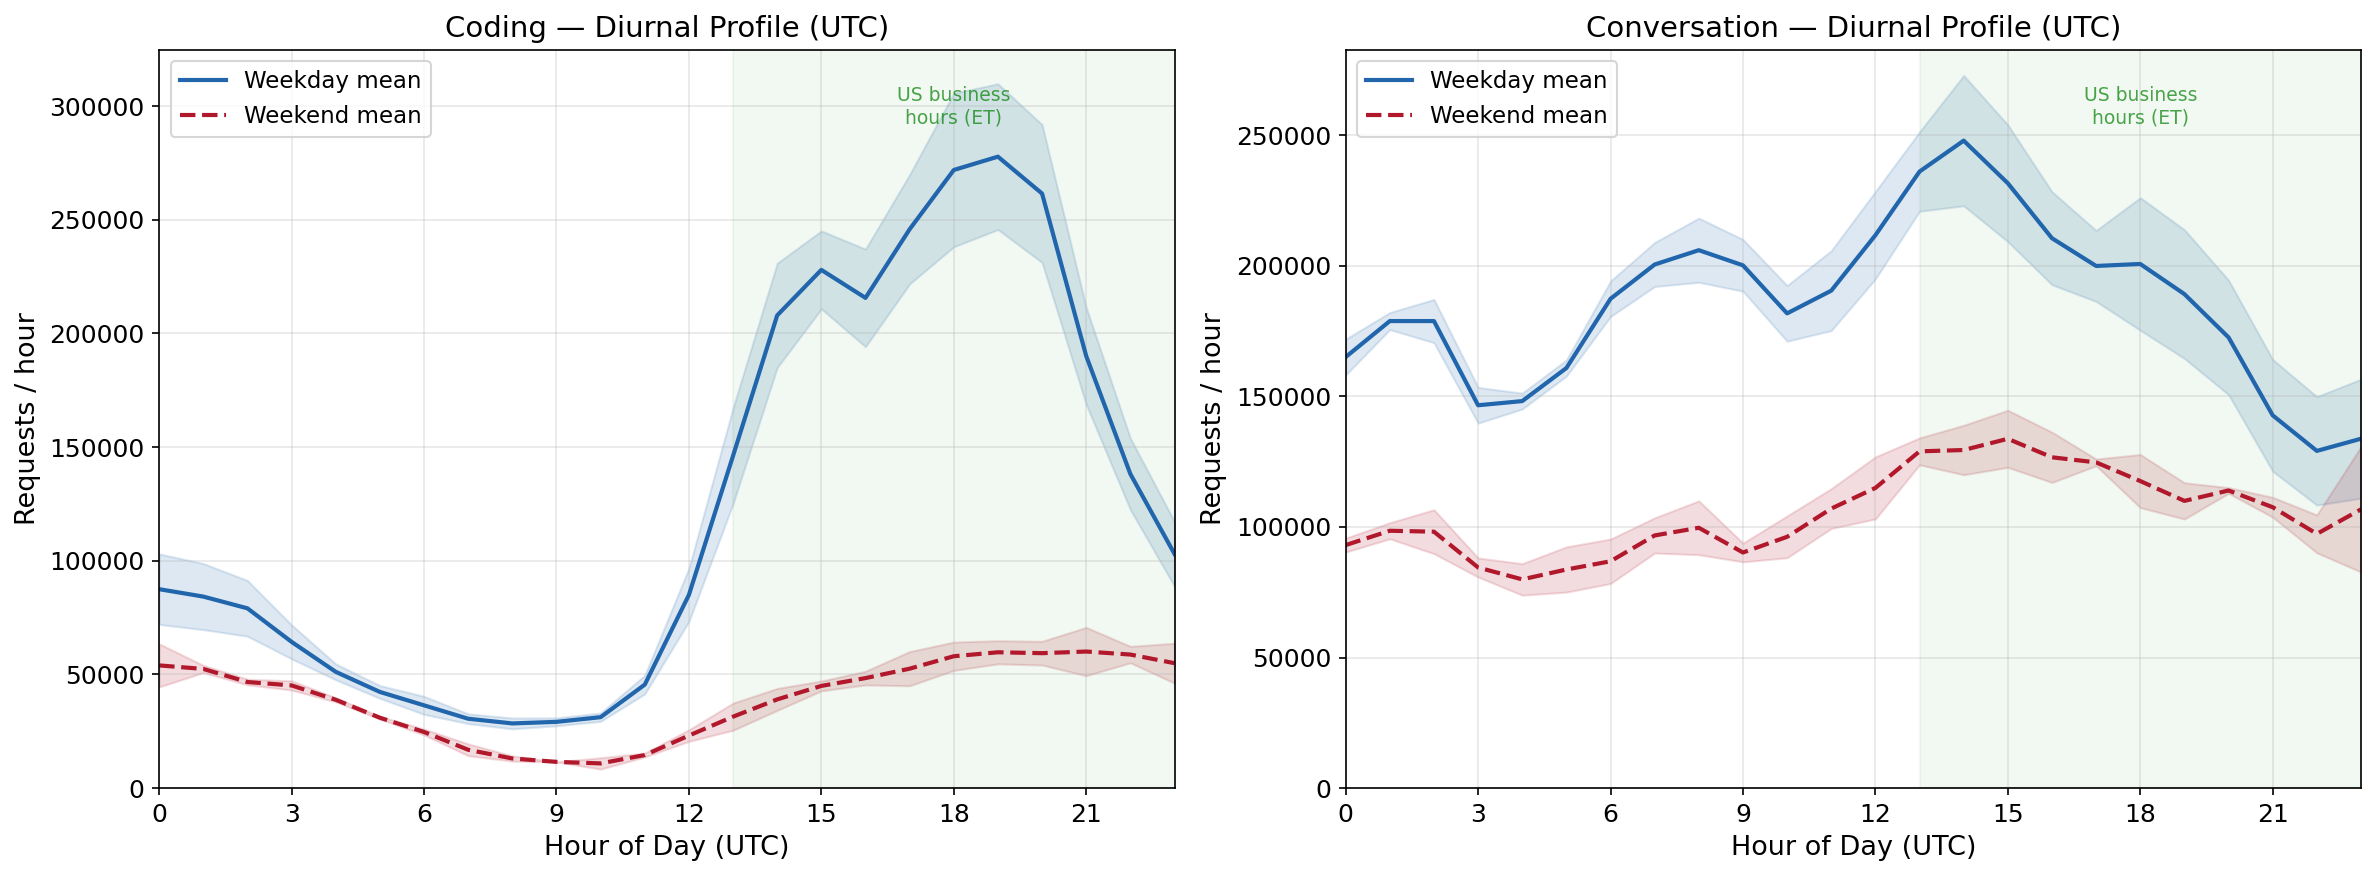

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, h) in enumerate(hourly.items()):
    ax = axes[i]
    
    # Separate weekday and weekend
    for label, subset, color, ls in [
        ('Weekday', h[~h['is_weekend']], '#2166ac', '-'),
        ('Weekend', h[h['is_weekend']], '#b2182b', '--'),
    ]:
        profile = subset.groupby('hour_of_day')['request_count'].agg(['mean', 'std', 'min', 'max'])
        
        ax.plot(profile.index, profile['mean'], label=f'{label} mean',
                color=color, linestyle=ls, linewidth=2)
        ax.fill_between(profile.index, 
                        profile['mean'] - profile['std'],
                        profile['mean'] + profile['std'],
                        alpha=0.15, color=color)
    
    ax.set_title(f'{name} — Diurnal Profile (UTC)')
    ax.set_xlabel('Hour of Day (UTC)')
    ax.set_ylabel('Requests / hour')
    ax.set_xlim(0, 23)
    ax.set_ylim(bottom=0)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Annotate US business hours (approx 13:00-01:00 UTC = 9am-9pm ET)
    ax.axvspan(13, 23, alpha=0.05, color='green')
    ax.text(18, ax.get_ylim()[1] * 0.95, 'US business\nhours (ET)', 
            ha='center', va='top', fontsize=9, color='green', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/diurnal_profile.png')
plt.show()

In [12]:
# === WEEKEND vs WEEKDAY QUANTIFICATION ===

print('=' * 70)
print('WEEKEND vs WEEKDAY LOAD')
print('=' * 70)

for name, h in hourly.items():
    wd_mean = h[~h['is_weekend']]['request_count'].mean()
    we_mean = h[h['is_weekend']]['request_count'].mean()
    reduction = 1 - (we_mean / wd_mean)
    
    wd_tok = h[~h['is_weekend']]['total_tokens'].mean()
    we_tok = h[h['is_weekend']]['total_tokens'].mean()
    reduction_tok = 1 - (we_tok / wd_tok)
    
    print(f'\n{name}:')
    print(f'  Weekday avg requests/hr: {wd_mean:,.0f}')
    print(f'  Weekend avg requests/hr: {we_mean:,.0f}')
    print(f'  Weekend reduction (requests): {reduction:.1%}')
    print(f'  Weekend reduction (tokens):   {reduction_tok:.1%}')

WEEKEND vs WEEKDAY LOAD

Coding:
  Weekday avg requests/hr: 124,202
  Weekend avg requests/hr: 39,572
  Weekend reduction (requests): 68.1%
  Weekend reduction (tokens):   72.3%

Conversation:
  Weekday avg requests/hr: 185,431
  Weekend avg requests/hr: 105,255
  Weekend reduction (requests): 43.2%
  Weekend reduction (tokens):   42.7%


---
## 6. Destination Headroom Analysis

**Key question:** If we need to migrate load FROM facility A during a DR event,  
how much spare capacity exists at facility B?  

Model this as: for each hour, what fraction of the weekly peak is utilized?  
The complement is the headroom available to absorb incoming migrated load.

DESTINATION HEADROOM (% of peak capacity unutilized)

Coding:
  25th percentile headroom: 48.5% of peak
  Median headroom:          79.8% of peak
  75th percentile headroom: 87.5% of peak
  → Median hour has 80% spare capacity to absorb migrated load

Conversation:
  25th percentile headroom: 26.2% of peak
  Median headroom:          38.2% of peak
  75th percentile headroom: 54.1% of peak
  → Median hour has 38% spare capacity to absorb migrated load


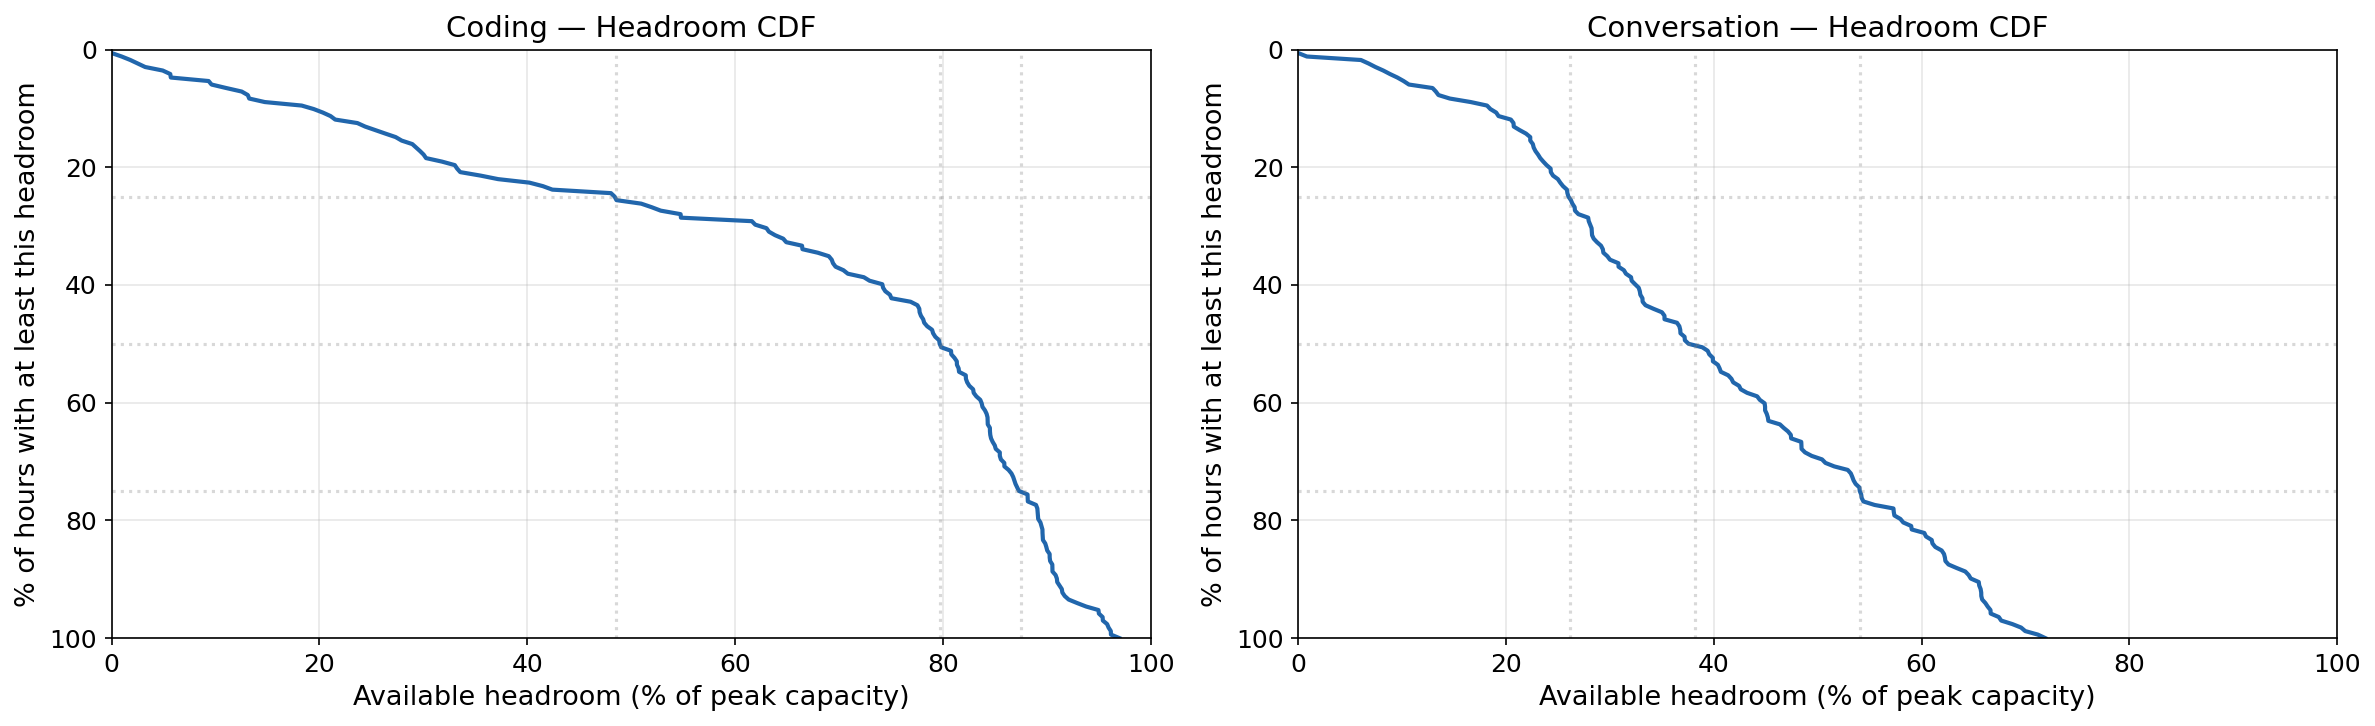

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

print('=' * 70)
print('DESTINATION HEADROOM (% of peak capacity unutilized)')
print('=' * 70)

for i, (name, h) in enumerate(hourly.items()):
    ax = axes[i]
    
    # Utilization as fraction of observed peak
    peak = h['request_count'].max()
    h_plot = h.copy()
    h_plot['utilization'] = h_plot['request_count'] / peak
    h_plot['headroom'] = 1 - h_plot['utilization']
    
    # CDF of headroom across all hours
    headroom_sorted = np.sort(h_plot['headroom'].values)
    cdf = np.arange(1, len(headroom_sorted) + 1) / len(headroom_sorted)
    
    ax.plot(headroom_sorted * 100, cdf * 100, linewidth=2, color='#2166ac')
    ax.set_title(f'{name} — Headroom CDF')
    ax.set_xlabel('Available headroom (% of peak capacity)')
    ax.set_ylabel('% of hours with at least this headroom')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    # Invert y so it reads as "X% of hours have >= Y% headroom"
    ax.invert_yaxis()
    
    # Key percentiles
    for pct in [25, 50, 75]:
        val = np.percentile(h_plot['headroom'].values, pct) * 100
        ax.axhline(y=pct, color='gray', linestyle=':', alpha=0.3)
        ax.axvline(x=val, color='gray', linestyle=':', alpha=0.3)
    
    p25 = np.percentile(h_plot['headroom'], 25) * 100
    p50 = np.percentile(h_plot['headroom'], 50) * 100
    p75 = np.percentile(h_plot['headroom'], 75) * 100
    
    print(f'\n{name}:')
    print(f'  25th percentile headroom: {p25:.1f}% of peak')
    print(f'  Median headroom:          {p50:.1f}% of peak')
    print(f'  75th percentile headroom: {p75:.1f}% of peak')
    print(f'  → Median hour has {p50:.0f}% spare capacity to absorb migrated load')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/headroom_cdf.png')
plt.show()

---
## 7. Request Duration & Facility Drain Time

**Target parameter:** Time to drain in-flight requests after stop-routing decision  
**P1 relevance:** DR response time = load balancer switch time + drain time  

We estimate request duration from output tokens ÷ serving throughput.  
Using DynamoLLM's reported range: 30–100 tokens/sec depending on config.

REQUEST DURATION ESTIMATES



Coding (16,803,695 requests):
  Output token percentiles:


    P50: 8 tokens


    P90: 43 tokens


    P95: 79 tokens


...

    P50:       1.4s       0.7s       0.4s


    P90:      11.4s       5.7s       3.4s


    P95:      15.2s       7.6s       4.5s


    P99:      23.1s      11.6s       6.9s


  → Facility drain time (P99): 23–7s


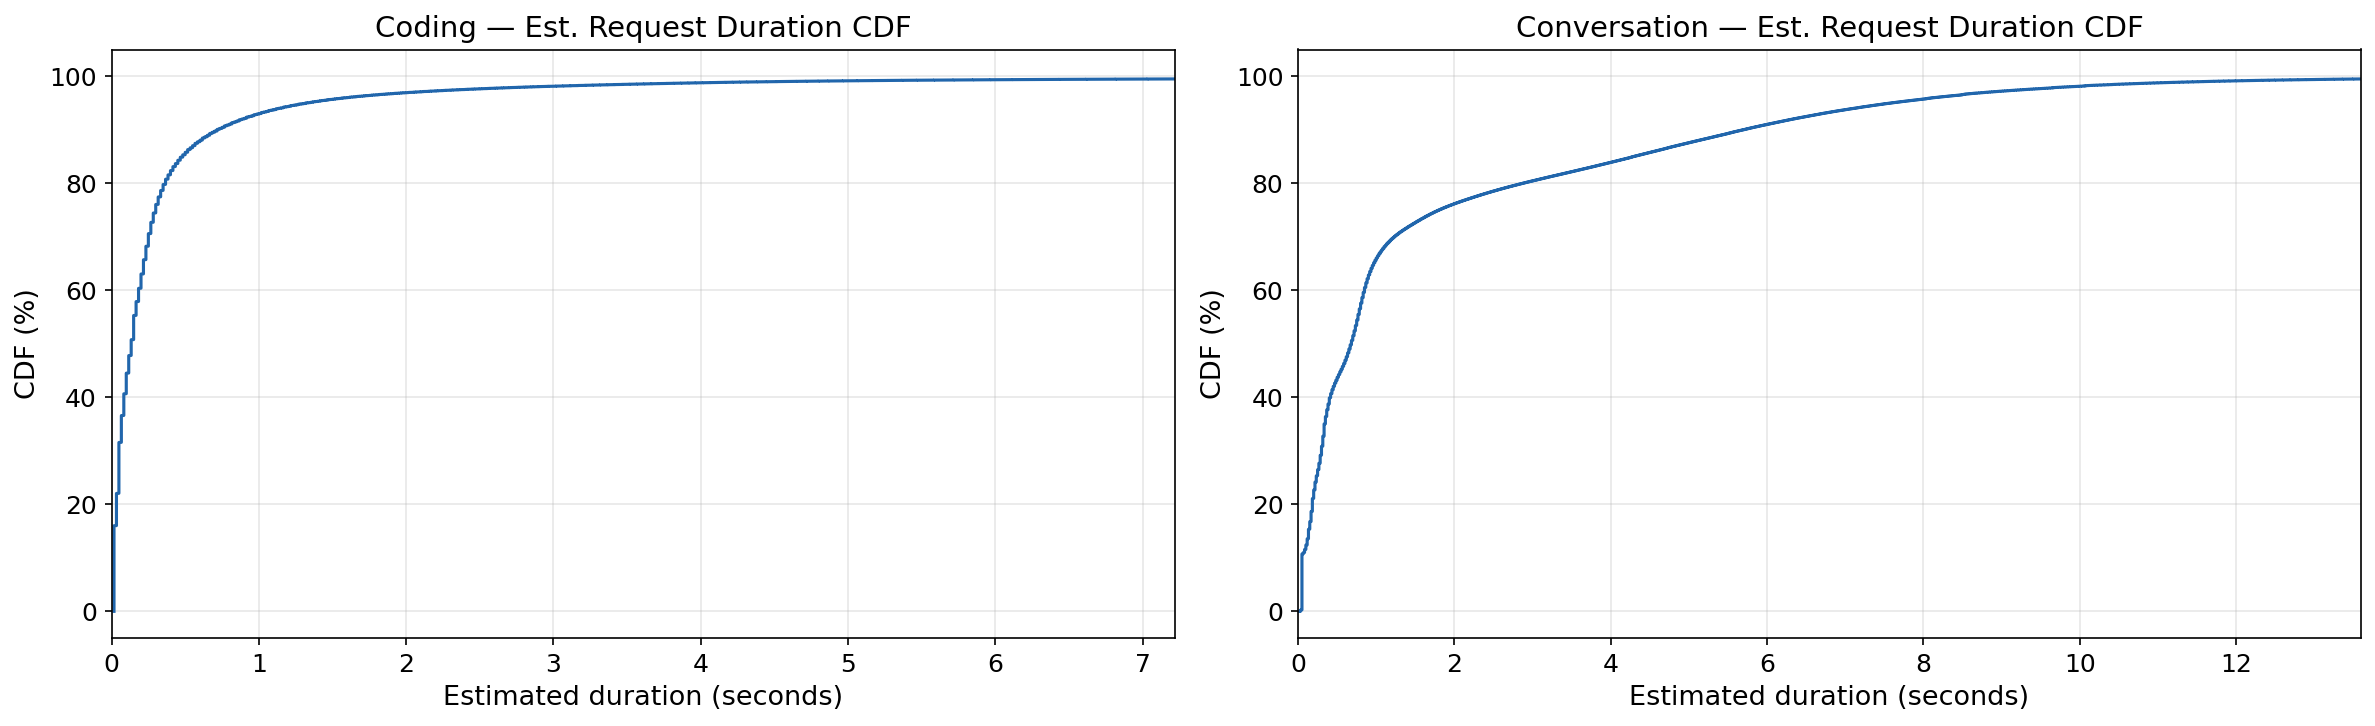

In [14]:
# Serving throughput assumptions (tokens/sec per request)
# DynamoLLM reports variable rates depending on model size and GPU config
THROUGHPUT_LOW = 30    # conservative: large model, power-constrained
THROUGHPUT_MID = 60    # typical
THROUGHPUT_HIGH = 100  # optimistic: small model, full power

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

print('=' * 70)
print('REQUEST DURATION ESTIMATES')
print('=' * 70)

for i, (name, df) in enumerate(traces.items()):
    ax = axes[i]
    
    gen_tokens = df['GeneratedTokens'].values
    
    # Duration estimates at mid throughput
    duration_sec = gen_tokens / THROUGHPUT_MID
    
    # CDF
    sorted_dur = np.sort(duration_sec)
    cdf = np.arange(1, len(sorted_dur) + 1) / len(sorted_dur) * 100
    
    ax.plot(sorted_dur, cdf, linewidth=1.5, color='#2166ac')
    ax.set_title(f'{name} — Est. Request Duration CDF')
    ax.set_xlabel('Estimated duration (seconds)')
    ax.set_ylabel('CDF (%)')
    ax.set_xlim(0, min(60, sorted_dur[int(len(sorted_dur) * 0.995)]))  # zoom to P99.5
    ax.grid(True, alpha=0.3)
    
    # Key percentiles across throughput assumptions
    print(f'\n{name} ({len(df):,} requests):')
    print(f'  Output token percentiles:')
    for p in [50, 90, 95, 99]:
        val = np.percentile(gen_tokens, p)
        print(f'    P{p}: {val:.0f} tokens')
    
    print(f'  Estimated request duration (seconds):')
    print(f'  {"":>6s} {"@30 tok/s":>10s} {"@60 tok/s":>10s} {"@100 tok/s":>10s}')
    for p in [50, 90, 95, 99]:
        val = np.percentile(gen_tokens, p)
        print(f'    P{p:>2d}: {val/THROUGHPUT_LOW:>9.1f}s {val/THROUGHPUT_MID:>9.1f}s {val/THROUGHPUT_HIGH:>9.1f}s')
    
    # Drain time = P99 request duration (worst case: last request started just before cutoff)
    p99 = np.percentile(gen_tokens, 99)
    print(f'  → Facility drain time (P99): {p99/THROUGHPUT_LOW:.0f}–{p99/THROUGHPUT_HIGH:.0f}s')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/request_duration_cdf.png')
plt.show()

---
## 8. Drain Simulation

Simulate: at time T, we stop routing new requests. How long until load drops to X%?  
Uses the empirical output token distribution and throughput assumptions.

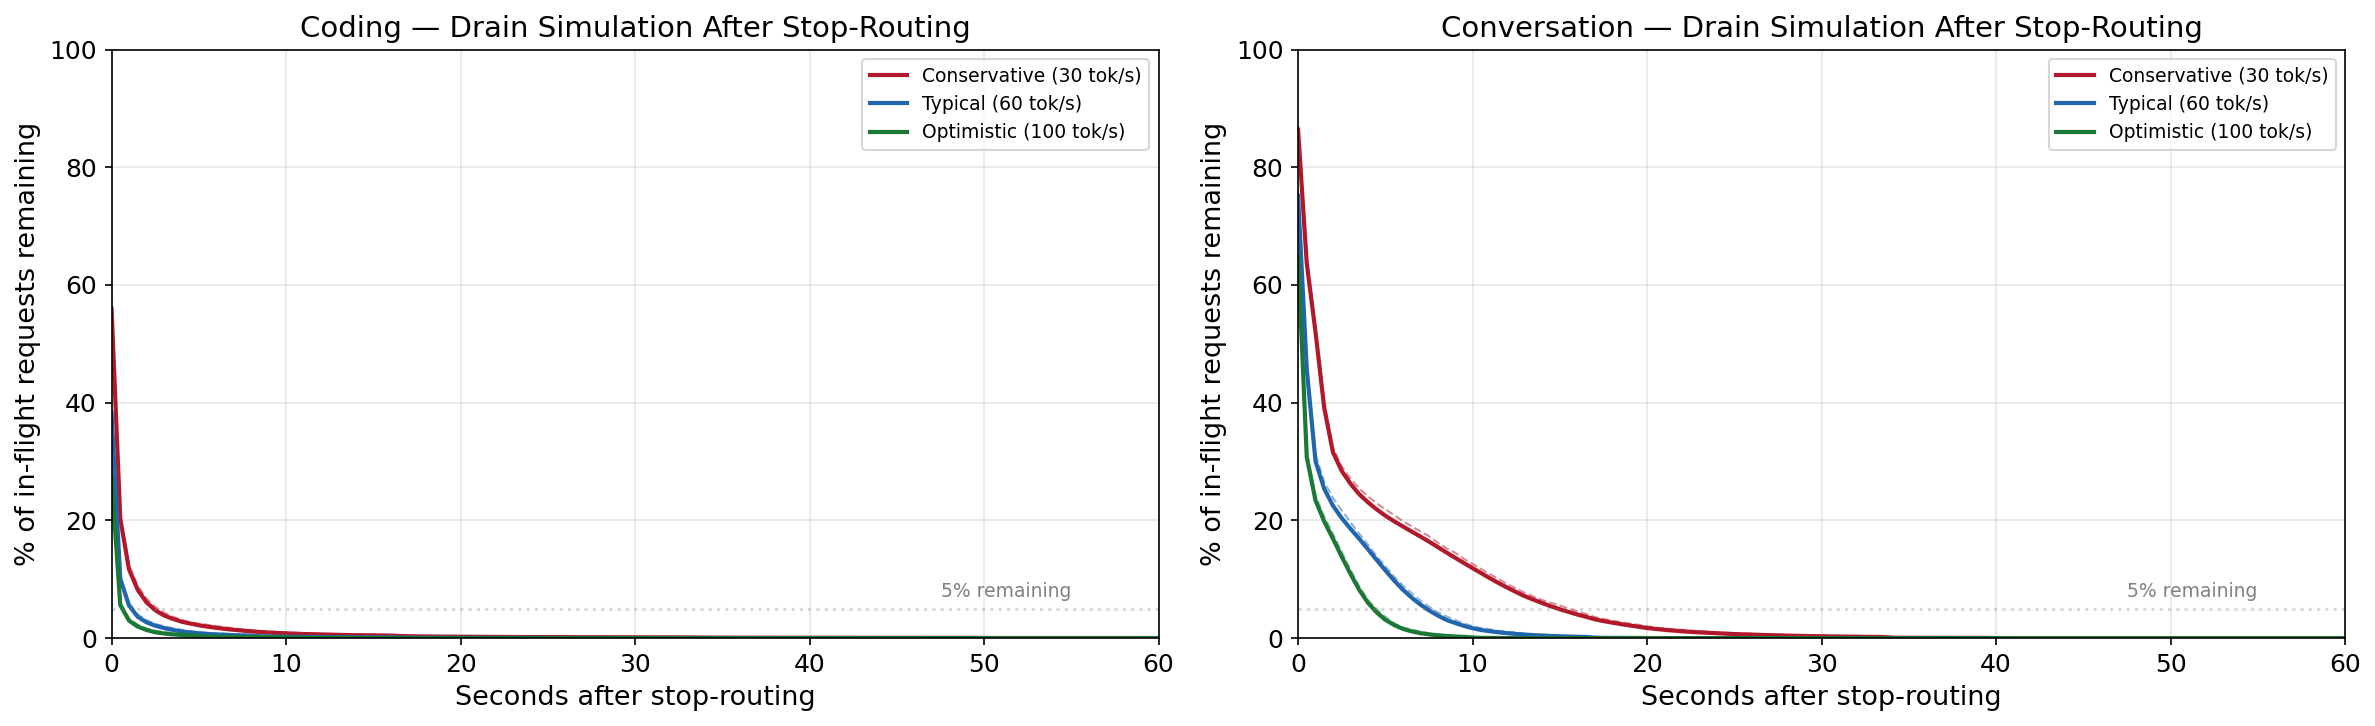

Solid lines = mean across simulations
Dashed lines = 95th percentile (worst-case)


In [15]:
def simulate_drain(gen_tokens_arr, throughput_tok_per_sec, n_simulations=50, 
                   window_sec=0.5, sample_size=5000):
    """
    Simulate facility drain after stop-routing.
    
    Assumes requests arrive uniformly in the last `window_sec` seconds before cutoff,
    each with a duration drawn from the empirical output token distribution.
    Returns time series of fraction of in-flight requests remaining.
    """
    results = []
    
    for _ in range(n_simulations):
        # Sample request output tokens from empirical distribution
        tokens = np.random.choice(gen_tokens_arr, size=sample_size, replace=True)
        durations = tokens / throughput_tok_per_sec
        
        # Requests arrived uniformly in last window_sec seconds before t=0
        arrival_offsets = np.random.uniform(-window_sec, 0, size=sample_size)
        completion_times = arrival_offsets + durations  # time after t=0 when each completes
        
        # What fraction remain at each second after cutoff?
        check_times = np.arange(0, 60.5, 0.5)
        remaining_frac = [(completion_times > t).mean() for t in check_times]
        results.append(remaining_frac)
    
    return np.arange(0, 60.5, 0.5), np.array(results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (name, df) in enumerate(traces.items()):
    ax = axes[i]
    gen_tokens = df['GeneratedTokens'].values
    
    for throughput, color, label in [
        (THROUGHPUT_LOW, '#b2182b', f'Conservative ({THROUGHPUT_LOW} tok/s)'),
        (THROUGHPUT_MID, '#2166ac', f'Typical ({THROUGHPUT_MID} tok/s)'),
        (THROUGHPUT_HIGH, '#1b7837', f'Optimistic ({THROUGHPUT_HIGH} tok/s)'),
    ]:
        times, results = simulate_drain(gen_tokens, throughput)
        mean_remaining = results.mean(axis=0) * 100
        p95_remaining = np.percentile(results, 95, axis=0) * 100
        
        ax.plot(times, mean_remaining, color=color, linewidth=2, label=label)
        ax.plot(times, p95_remaining, color=color, linewidth=1, linestyle='--', alpha=0.5)
    
    ax.set_title(f'{name} — Drain Simulation After Stop-Routing')
    ax.set_xlabel('Seconds after stop-routing')
    ax.set_ylabel('% of in-flight requests remaining')
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.axhline(y=5, color='gray', linestyle=':', alpha=0.3)
    ax.text(55, 7, '5% remaining', fontsize=9, ha='right', color='gray')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/drain_simulation.png')
plt.show()

print('Solid lines = mean across simulations')
print('Dashed lines = 95th percentile (worst-case)')

---
## 9. Token Distributions (Request-Level Characterization)

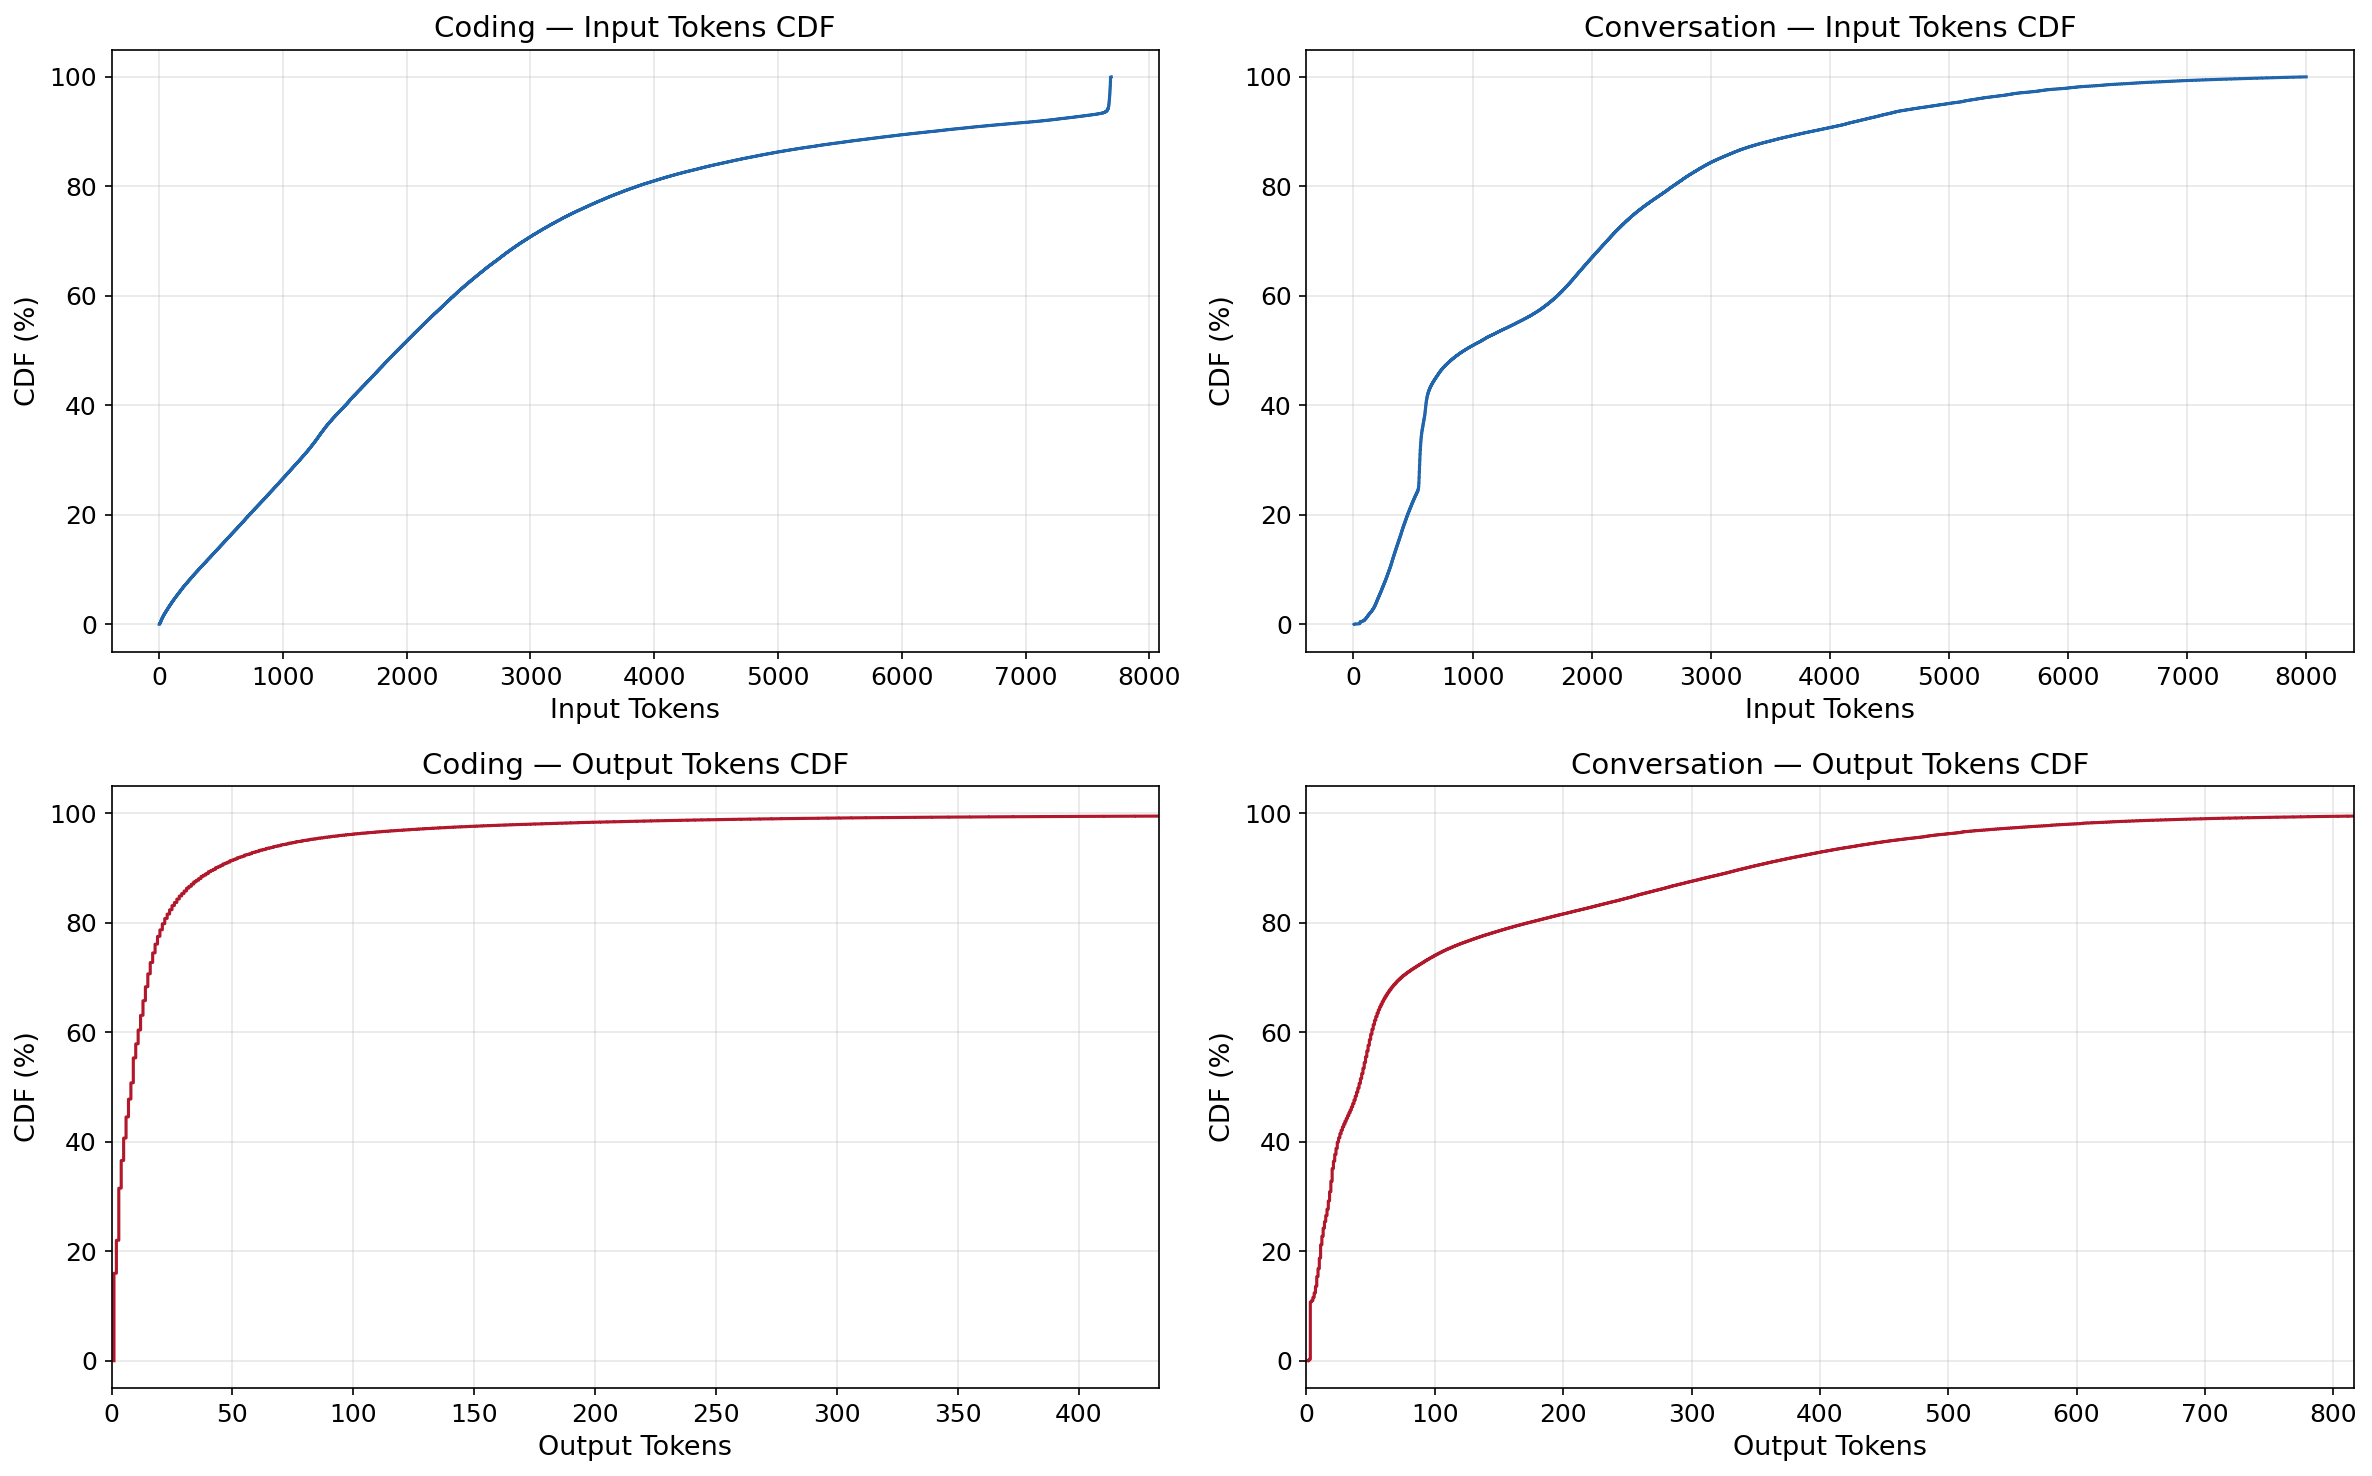

TOKEN DISTRIBUTION SUMMARY

Coding:
  ContextTokens:


    Mean: 2511, Median: 1930


    P90: 6251, P99: 7685
    Max: 7743
  GeneratedTokens:


    Mean: 23, Median: 8


    P90: 43, P99: 271
    Max: 5000

Conversation:
  ContextTokens:


    Mean: 1632, Median: 928


    P90: 3830, P99: 6683
    Max: 7999
  GeneratedTokens:


    Mean: 106, Median: 41


    P90: 342, P99: 694
    Max: 1500


In [16]:
# === TOKEN DISTRIBUTIONS (memory-safe: sample-based CDF) ===
SAMPLE_N = 500_000  # 500K sample is plenty for smooth CDFs

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, (name, df) in enumerate(traces.items()):
    for j, (col, title, color) in enumerate([
        ('ContextTokens', 'Input Tokens', '#2166ac'),
        ('GeneratedTokens', 'Output Tokens', '#b2182b'),
    ]):
        ax = axes[j, i]
        
        # Sample instead of sorting full array
        sample = df[col].sample(n=min(SAMPLE_N, len(df)), random_state=42).values
        sample.sort()  # in-place sort on small array
        cdf = np.arange(1, len(sample) + 1) / len(sample) * 100
        
        ax.plot(sample, cdf, linewidth=1.5, color=color)
        ax.set_title(f'{name} — {title} CDF')
        ax.set_xlabel(f'{title}')
        ax.set_ylabel('CDF (%)')
        ax.grid(True, alpha=0.3)
        
        if col == 'GeneratedTokens':
            ax.set_xlim(0, df[col].quantile(0.995))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/token_distributions.png')
plt.show()

# Summary stats (these are computed on the full data, no memory issue)
print('=' * 70)
print('TOKEN DISTRIBUTION SUMMARY')
print('=' * 70)
for name, df in traces.items():
    print(f'\n{name}:')
    for col in ['ContextTokens', 'GeneratedTokens']:
        print(f'  {col}:')
        print(f'    Mean: {df[col].mean():.0f}, Median: {df[col].median():.0f}')
        print(f'    P90: {df[col].quantile(0.9):.0f}, P99: {df[col].quantile(0.99):.0f}')
        print(f'    Max: {df[col].max()}')

---
## 10. Inter-Arrival Time Analysis (Request Independence)

**Target parameter:** Evidence for/against request-level independence (Factor A)  
**Method:** If requests are independent, inter-arrival times should be approximately exponential

Coding (chunk of 2,000,000 requests):
  Mean inter-arrival: 19.06 ms
  Median inter-arrival: 2.34 ms
  Implied request rate: 52 req/sec



Conversation (chunk of 2,000,000 requests):
  Mean inter-arrival: 15.33 ms
  Median inter-arrival: 1.37 ms
  Implied request rate: 65 req/sec



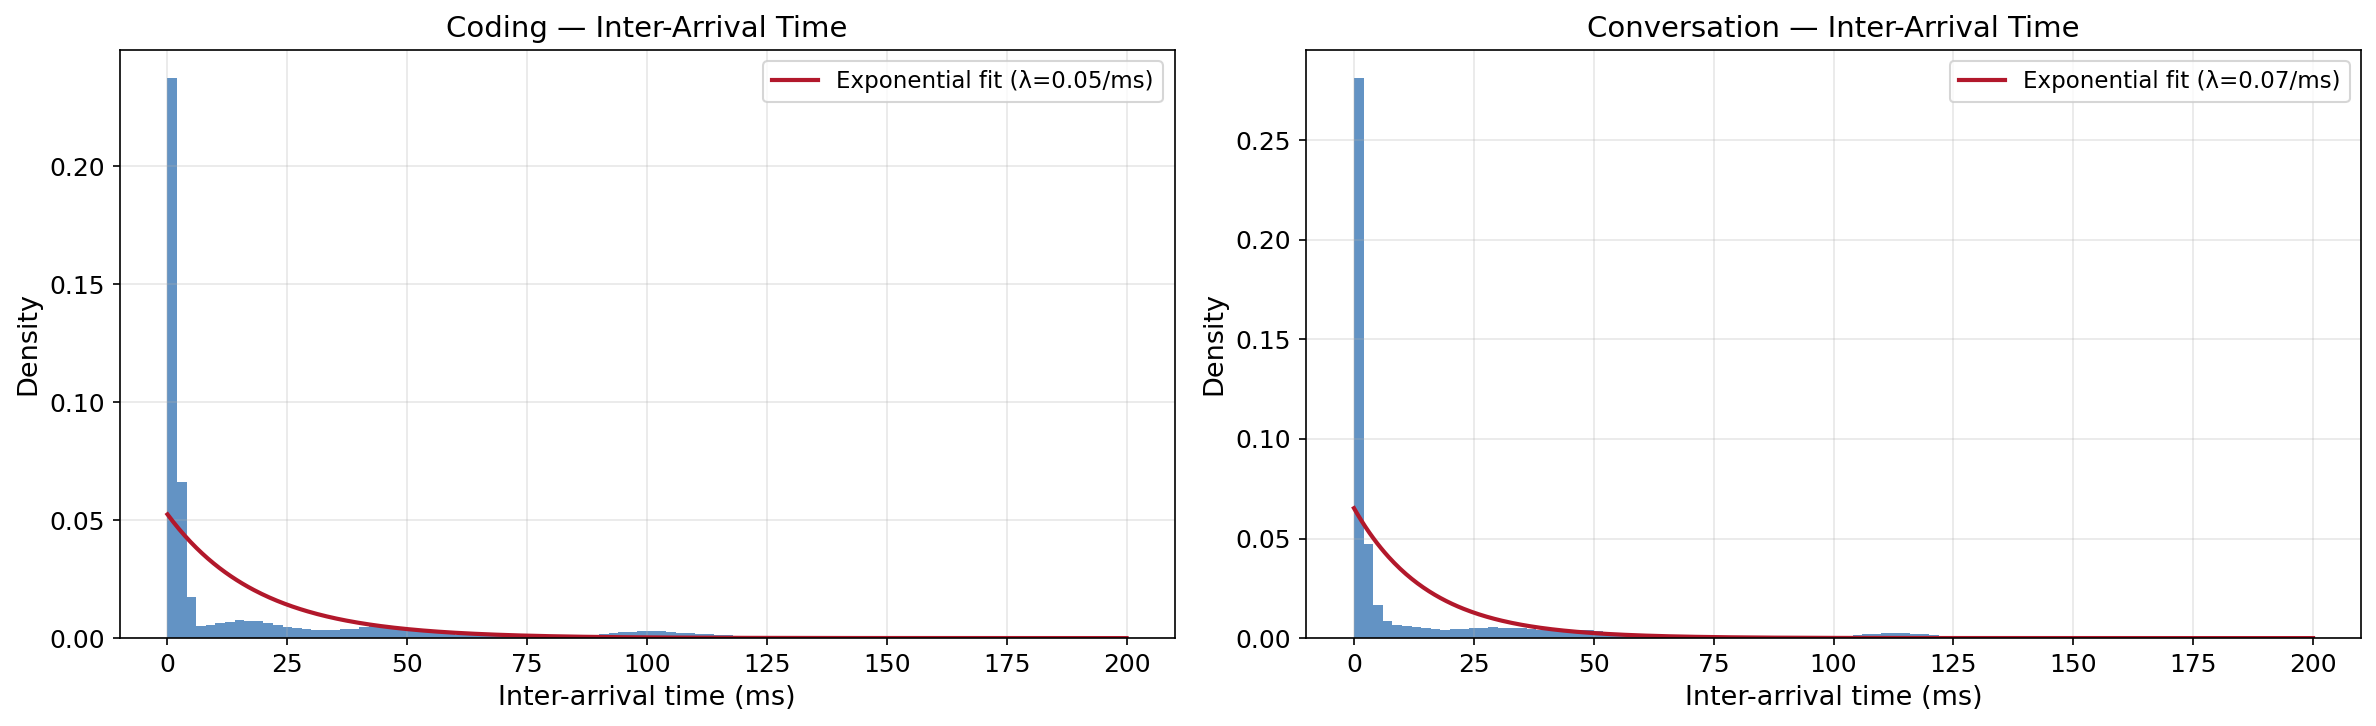

If distribution matches exponential → consistent with independent Poisson arrivals
Deviations from exponential suggest burstiness or correlated arrivals


In [17]:
# === INTER-ARRIVAL TIME ANALYSIS (memory-safe) ===
# Compute IAT on a contiguous chunk rather than full diff

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

CHUNK_SIZE = 2_000_000  # compute diff on 2M contiguous rows at a time

for i, (name, df) in enumerate(traces.items()):
    ax = axes[i]
    
    # Take a contiguous chunk from the middle of the trace
    start = len(df) // 3
    chunk = df.iloc[start:start + CHUNK_SIZE].copy()
    
    iat_ms = chunk['TIMESTAMP'].diff().dt.total_seconds().dropna() * 1000
    iat_ms = iat_ms[iat_ms > 0]
    
    # Use histogram instead of plotting all points
    bins = np.linspace(0, 200, 101)
    counts, edges = np.histogram(iat_ms.values, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    
    ax.bar(centers, counts, width=edges[1] - edges[0], alpha=0.7,
           color='#2166ac', edgecolor='none')
    
    # Exponential fit
    rate = 1.0 / iat_ms.mean()
    x_fit = np.linspace(0, 200, 500)
    ax.plot(x_fit, rate * np.exp(-rate * x_fit), color='#b2182b',
            linewidth=2, label=f'Exponential fit (λ={rate:.2f}/ms)')
    
    ax.set_title(f'{name} — Inter-Arrival Time')
    ax.set_xlabel('Inter-arrival time (ms)')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    print(f'{name} (chunk of {len(chunk):,} requests):')
    print(f'  Mean inter-arrival: {iat_ms.mean():.2f} ms')
    print(f'  Median inter-arrival: {iat_ms.median():.2f} ms')
    print(f'  Implied request rate: {1000/iat_ms.mean():.0f} req/sec')
    print()
    
    del chunk, iat_ms  # free memory

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/interarrival_times.png')
plt.show()

print('If distribution matches exponential → consistent with independent Poisson arrivals')
print('Deviations from exponential suggest burstiness or correlated arrivals')

---
## 11. Compute-Weighted Load Profile

Request count isn't the whole story — a request with 8K context tokens uses  
far more GPU compute than one with 100 tokens. Build token-weighted profiles.

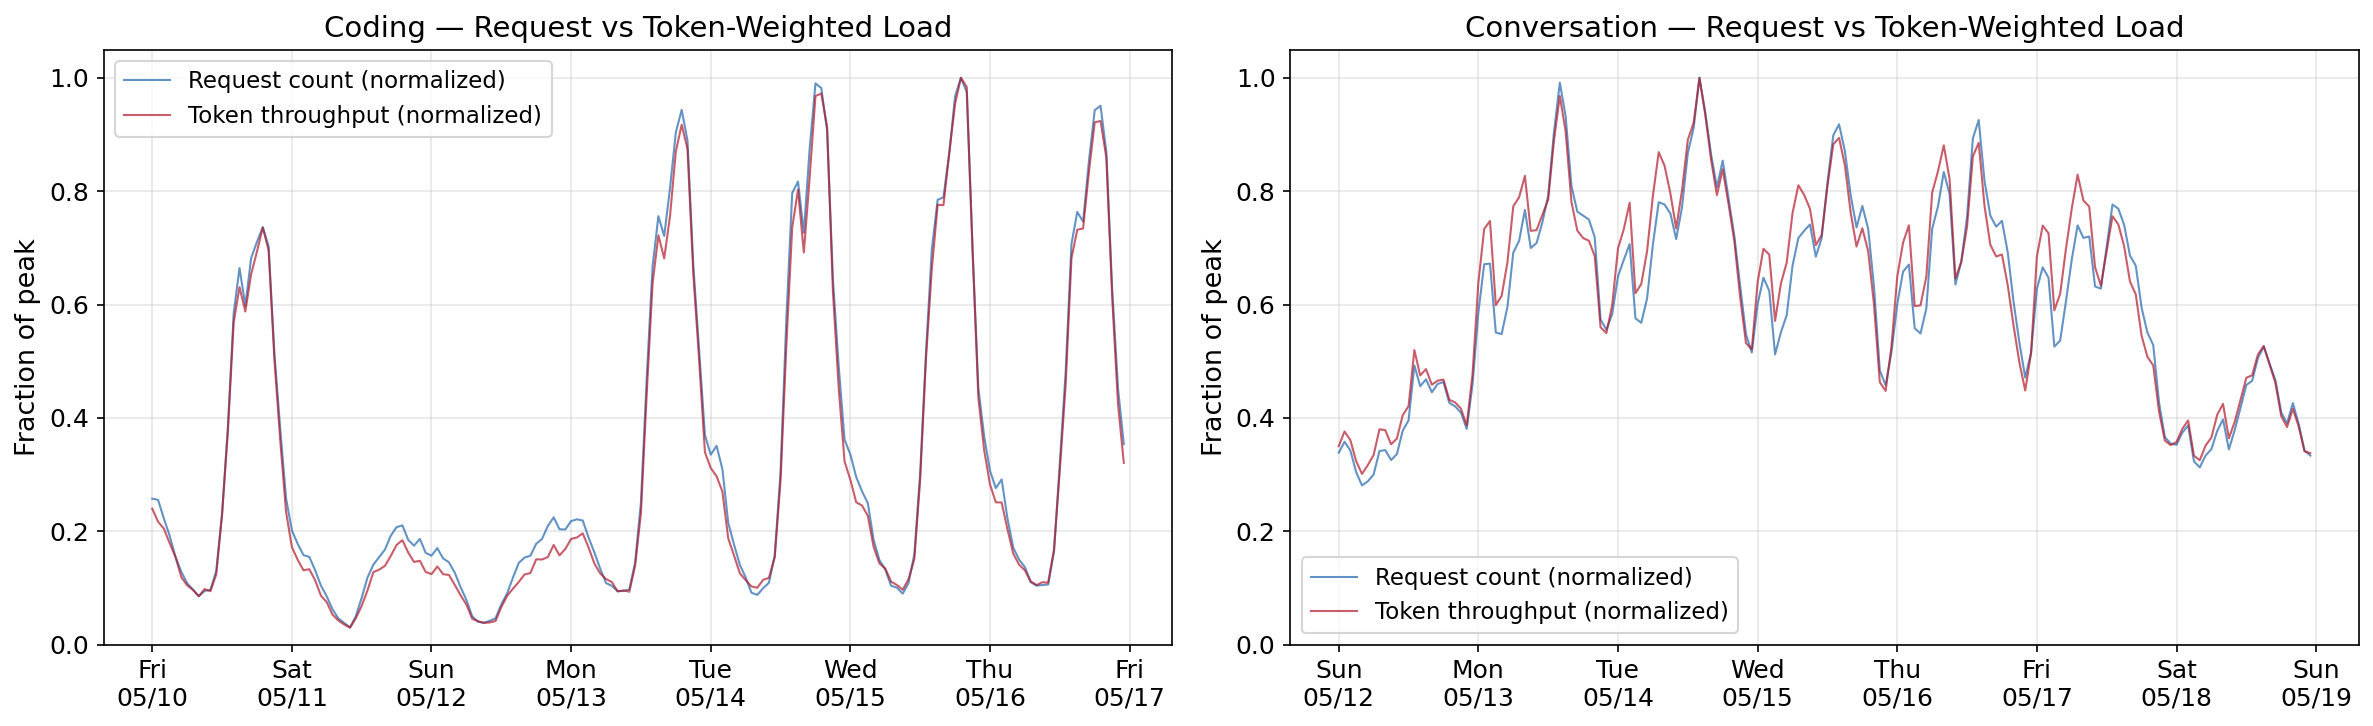

Coding: correlation(request_count, total_tokens) = 0.9985
Conversation: correlation(request_count, total_tokens) = 0.9755


In [18]:
# === COMPUTE-WEIGHTED LOAD PROFILE ===
# This uses hourly aggregates only — no memory issue

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (name, h) in enumerate(hourly.items()):
    ax = axes[i]
    
    req_norm = h['request_count'] / h['request_count'].max()
    tok_norm = h['total_tokens'] / h['total_tokens'].max()
    
    ax.plot(h.index, req_norm, label='Request count (normalized)',
            color='#2166ac', linewidth=1, alpha=0.7)
    ax.plot(h.index, tok_norm, label='Token throughput (normalized)',
            color='#b2182b', linewidth=1, alpha=0.7)
    
    ax.set_title(f'{name} — Request vs Token-Weighted Load')
    ax.set_ylabel('Fraction of peak')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%m/%d'))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/request_vs_token_weighted.png')
plt.show()

for name, h in hourly.items():
    r = h['request_count'].corr(h['total_tokens'])
    print(f'{name}: correlation(request_count, total_tokens) = {r:.4f}')

---
## 12. Summary: Extracted Parameters for P1 Bounded Derivation

All numbers derived from 44M production Azure LLM inference requests (May 2024).

In [19]:
print('=' * 70)
print('PARAMETER EXTRACTION SUMMARY')
print('Azure LLM Inference Traces (Stojkovic et al., HPCA 2025)')
print('44.1M requests, two production services, May 10-18 2024')
print('=' * 70)

for name, h in hourly.items():
    df = traces[name]
    
    cov_req = h['request_count'].std() / h['request_count'].mean()
    cov_tok = h['total_tokens'].std() / h['total_tokens'].mean()
    rho24_req = h['request_count'].autocorr(lag=24)
    rho24_tok = h['total_tokens'].autocorr(lag=24)
    
    wd = h[~h['is_weekend']]
    daily_pttr = []
    for date, day_data in wd.groupby(wd.index.date):
        if len(day_data) >= 20:
            daily_pttr.append(day_data['request_count'].max() / day_data['request_count'].min())
    
    wd_mean = h[~h['is_weekend']]['request_count'].mean()
    we_mean = h[h['is_weekend']]['request_count'].mean()
    wknd_reduction = 1 - (we_mean / wd_mean) if we_mean > 0 and wd_mean > 0 else np.nan
    
    peak = h['request_count'].max()
    median_headroom = 1 - (h['request_count'].median() / peak)
    
    p99_gen = df['GeneratedTokens'].quantile(0.99)
    drain_p99 = p99_gen / THROUGHPUT_MID
    
    print(f'\n--- {name} ---')
    print(f'  Hourly request CoV:           {cov_req:.3f}')
    print(f'  Hourly token CoV:             {cov_tok:.3f}')
    print(f'  24h autocorrelation (req):    {rho24_req:.4f}')
    print(f'  24h autocorrelation (tok):    {rho24_tok:.4f}')
    if daily_pttr:
        print(f'  Weekday PTTR (mean):          {np.mean(daily_pttr):.1f}:1')
    print(f'  Weekend load reduction:       {wknd_reduction:.1%}' if not np.isnan(wknd_reduction) else '  Weekend load reduction:       N/A')
    print(f'  Median headroom (vs peak):    {median_headroom:.1%}')
    print(f'  P99 drain time (@{THROUGHPUT_MID} tok/s):  {drain_p99:.1f}s')

print('\n' + '=' * 70)
print('CITABLE PARAMETER TABLE')
print('=' * 70)
print(f'\nFigures saved to: {os.path.abspath(FIG_DIR)}/')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {f}')

PARAMETER EXTRACTION SUMMARY
Azure LLM Inference Traces (Stojkovic et al., HPCA 2025)
44.1M requests, two production services, May 10-18 2024



--- Coding ---
  Hourly request CoV:           0.848
  Hourly token CoV:             0.883
  24h autocorrelation (req):    0.7545
  24h autocorrelation (tok):    0.7415
  Weekday PTTR (mean):          10.0:1
  Weekend load reduction:       68.1%
  Median headroom (vs peak):    79.8%
  P99 drain time (@60 tok/s):  4.5s



--- Conversation ---
  Hourly request CoV:           0.291
  Hourly token CoV:             0.284
  24h autocorrelation (req):    0.3995
  24h autocorrelation (tok):    0.3607
  Weekday PTTR (mean):          2.0:1
  Weekend load reduction:       43.2%
  Median headroom (vs peak):    38.2%
  P99 drain time (@60 tok/s):  11.6s

CITABLE PARAMETER TABLE

Figures saved to: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\archive\figures_azure_trace/
  autocorrelation.png
  diurnal_profile.png
  diurnal_timeseries.png
  drain_simulation.png
  headroom_cdf.png
  interarrival_times.png
  request_duration_cdf.png
  request_vs_token_weighted.png
  token_distributions.png
